# Heart Disease Prediction using Decision Tree Classifier

## Project Overview

This project uses a Decision Tree Classifier to predict the presence of heart disease using patient medical attributes. The workflow includes data preprocessing, model training, evaluation, visualization, and hyperparameter tuning.

The project was implemented using Python, Pandas, Matplotlib, Seaborn, and Scikit-learn in Jupyter Notebook.


In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [33]:
df=pd.read_csv("decision_trees/archive/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [35]:
df.shape

(1025, 14)

In [37]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [39]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [86]:
df.drop_duplicates()
df.shape

(302, 14)


Duplicate rows were identified and removed to avoid data leakage and unrealistic model performance.

In [40]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [87]:
X=df.drop('target',axis=1)
y=df['target']

### Train-Test Split
The dataset was divided into training and testing sets using an 80-20 split.

In [88]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

### Building the Decision Tree Model

In [89]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

In [90]:
model.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [91]:
y_pred=model.predict(X_test)
y_pred[:10]

array([1, 1, 0, 0, 1, 0, 0, 1, 0, 1])

### Model Evaluation

In [92]:
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 0.7377049180327869


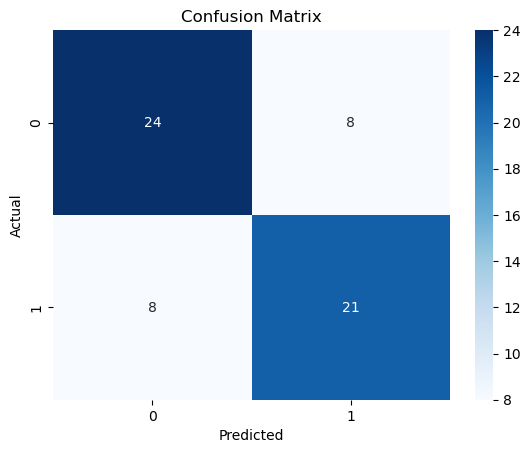

In [93]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        32
           1       0.72      0.72      0.72        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



### Decision Tree Visualisation

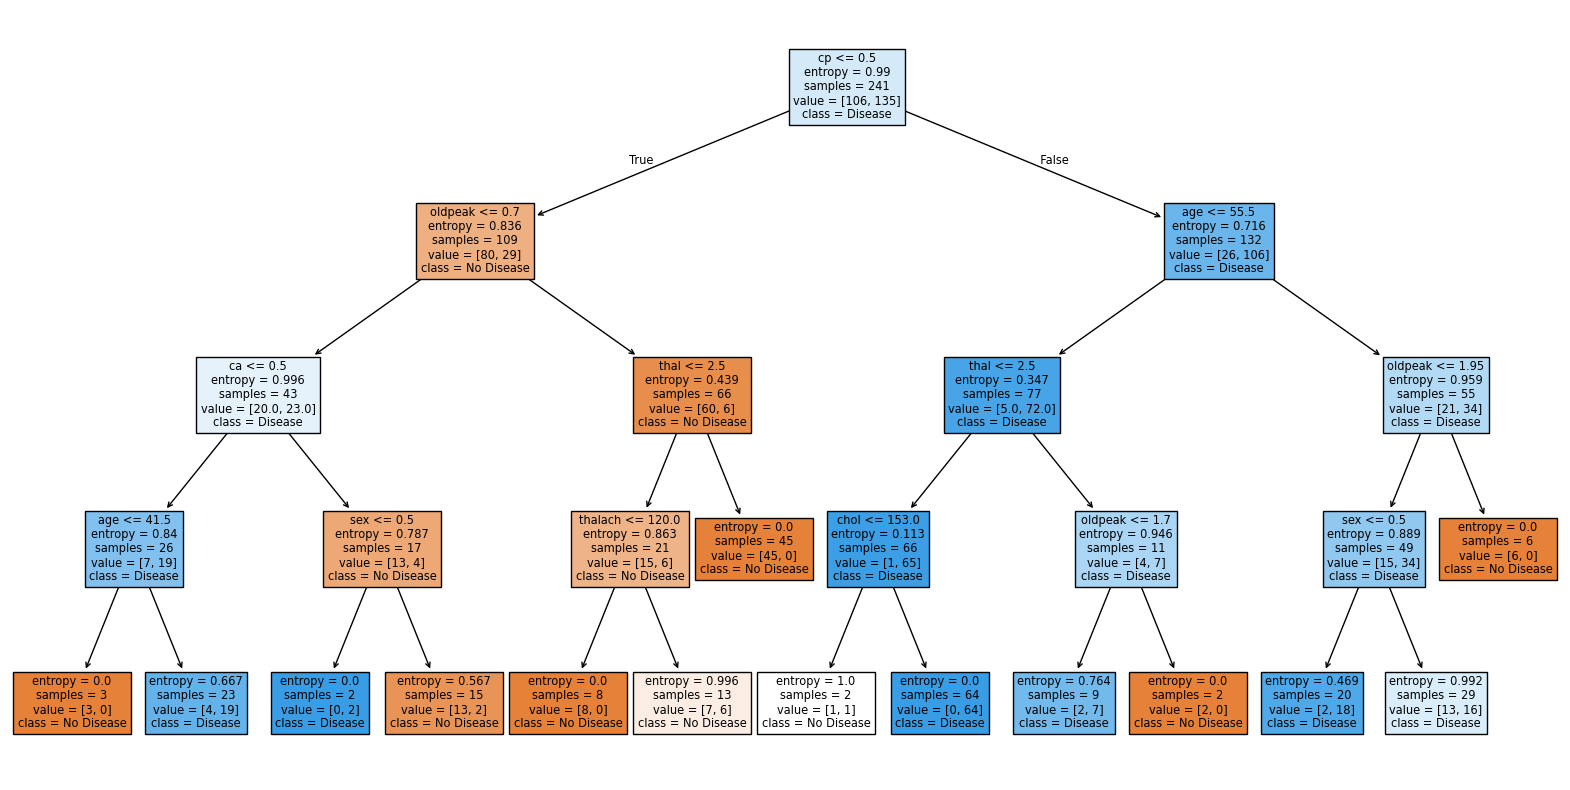

In [99]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)

plt.show()

In [100]:
importance=model.feature_importances_

features=pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
})
features=features.sort_values(by="Importance",ascending=False)

print(features)

     Feature  Importance
2         cp    0.341962
9    oldpeak    0.206788
0        age    0.139305
12      thal    0.127376
1        sex    0.066410
11        ca    0.049256
4       chol    0.035405
7    thalach    0.033498
3   trestbps    0.000000
5        fbs    0.000000
6    restecg    0.000000
8      exang    0.000000
10     slope    0.000000


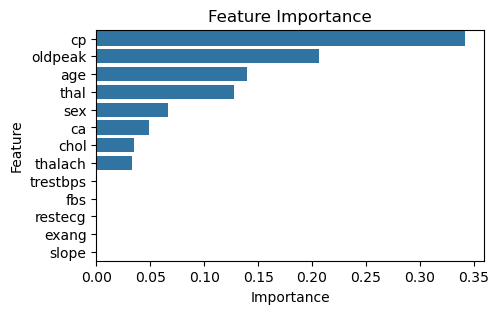

In [101]:
plt.figure(figsize=(5,3))
sns.barplot(
    x="Importance",
    y="Feature",
    data=features
)
plt.title("Feature Importance")
plt.show()

### Hyperparameter Tuning

Different values of max_depth were tested

In [102]:
depths=[1,2,3,4,5,6,7,8,9,10]
train_scores=[]
test_scores=[]

for d in depths:
    model=DecisionTreeClassifier(
        max_depth=d,
        criterion='entropy',
        random_state=43
    )
    model.fit(X_train,y_train)

    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)

    train_acc=accuracy_score(y_train,train_pred)
    test_acc=accuracy_score(y_test,test_pred)

    train_scores.append(train_acc)
    test_scores.append(test_acc)


In [103]:
results=pd.DataFrame({
    "depth":depths,
    "train accuracy":train_scores,
    "test accuracy": test_scores
})
print(results)

   depth  train accuracy  test accuracy
0      1        0.771784       0.704918
1      2        0.784232       0.704918
2      3        0.846473       0.737705
3      4        0.875519       0.737705
4      5        0.933610       0.704918
5      6        0.966805       0.754098
6      7        0.983402       0.737705
7      8        0.991701       0.737705
8      9        1.000000       0.704918
9     10        1.000000       0.704918


In [104]:
print(X_train.shape)
print(X_test.shape)
print(df.shape)

(241, 13)
(61, 13)
(302, 14)


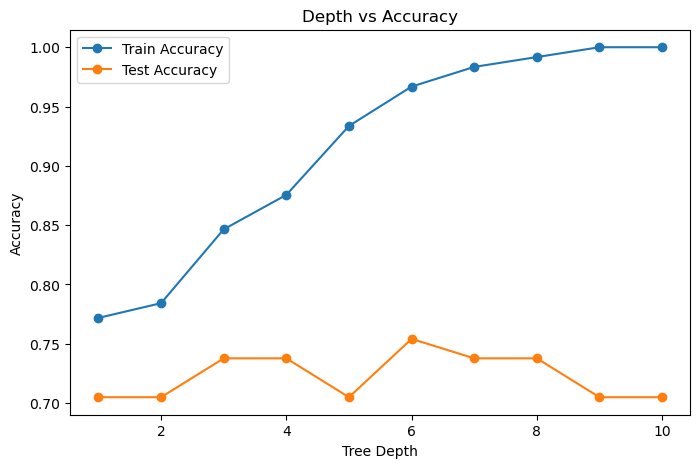

In [105]:
plt.figure(figsize=(8,5))

plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores, marker='o', label='Test Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Depth vs Accuracy")
plt.legend()
plt.show()

### Gini vs Entropy Comparison

In [106]:
gini_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

entropy_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

gini_model.fit(X_train, y_train)
entropy_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)
entropy_pred = entropy_model.predict(X_test)

gini_acc = accuracy_score(y_test, gini_pred)
entropy_acc = accuracy_score(y_test, entropy_pred)

print("Gini Accuracy:", gini_acc)
print("Entropy Accuracy:", entropy_acc)

Gini Accuracy: 0.7377049180327869
Entropy Accuracy: 0.7049180327868853


### Decision Boundary Visualization

A simplified 2-feature Decision Tree model was used to visualize the decision boundaries and understand how the classifier separates classes.

In [118]:
X_small = df[['age', 'oldpeak']]
y_small = df['target']

In [119]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42
)

In [120]:
small_model = DecisionTreeClassifier(
    max_depth=4,
    criterion='entropy',
    random_state=42
)

small_model.fit(X_train_s, y_train_s)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


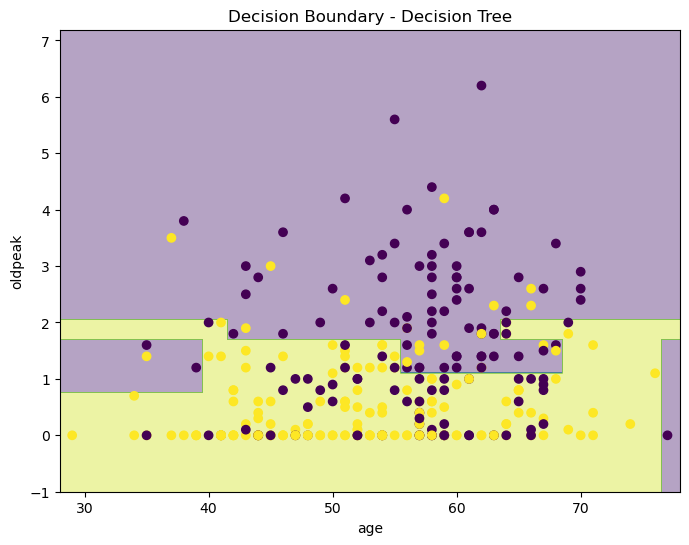

In [121]:
from matplotlib.colors import ListedColormap

x_min, x_max = X_small['age'].min() - 1, X_small['age'].max() + 1
y_min, y_max = X_small['oldpeak'].min() - 1, X_small['oldpeak'].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = small_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(
    X_small['age'],
    X_small['oldpeak'],
    c=y_small
)

plt.xlabel("age")
plt.ylabel("oldpeak")

plt.title("Decision Boundary - Decision Tree")

plt.show()

### ROC Curve and AUC Score

In [124]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:,1]

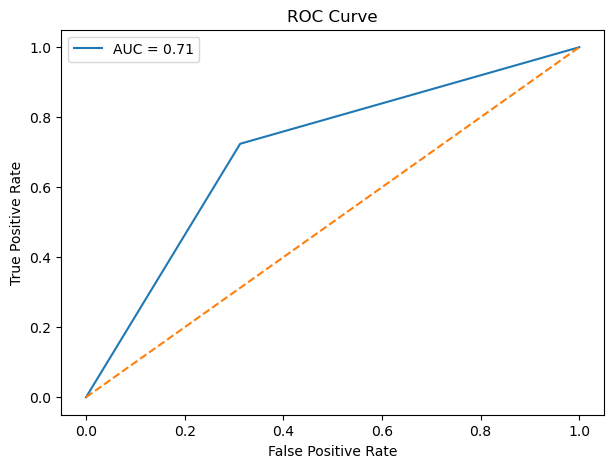

In [126]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()
plt.show()

# Final Observations and Conclusion

* Duplicate rows in the dataset initially caused unrealistically high accuracy due to data leakage.
* After removing duplicates, model performance became more realistic and reliable.
* Increasing tree depth improved training accuracy, but deeper trees started overfitting the training data.
* The best performance was observed around moderate depth values.
* Chest pain type (`cp`) was identified as the most important feature for prediction.
* Gini and Entropy produced similar results, with Gini performing slightly better on the cleaned dataset.
* The Decision Tree model successfully demonstrated classification, feature importance analysis, and overfitting behavior.
